In [9]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

cwd = Path(os.getcwd())

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc.llowfsc as llowfsc
import scoob_llowfsc.scoob_interface as scoobi
import scoob_llowfsc.utils as utils
import scoob_llowfsc.telem as telem
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9


In [11]:
reload(telem)

data_path = cwd/'data'/f'exp-{today}'
llowfsc_data_path = cwd/'data'/f'exp-{today}'/'llowfsc'
telem.make_dir(data_path)
telem.make_dir(llowfsc_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/notebooks/data/exp-20250212' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/notebooks/data/exp-20250212/llowfsc' created successfully.


In [ ]:
reload(scoobi)
I = scoobi.SCOOBI()

In [ ]:
fib_atten = 5
camlo_gain = 5
camlo_exp_time = 0.0001

I.set_fib_atten(fib_atten, client)
I.set_nsv_gain(camlo_gain, client0)
I.set_nsv_exp_time(camlo_exp_time, client0)

Set the fiber attenuation to 5.0
Set the NSV571 gain to 1.00e-04s
Set the NSV571 exposure time to 1.00e-04s


In [6]:
roi_region_h, roi_region_w, roi_region_x, vcropoffset  = (128, 128, 2602, 2512)

# client0.wait_for_properties(['camnsv.mode',])
# client0['camnsv.mode.sliced'] = purepyindi.SwitchState.ON

# client0.wait_for_properties(['client.roi_region_h', 'client.roi_region_w', 'client.roi_region_x', 'client.roi_set'])
# client0['camnsv.roi_region_h.target'] = nlocam
# client0['camnsv.roi_region_w.target'] = nlocam
# client0['camnsv.roi_region_x.target'] = xlocam
# client0['camnsv.roi_set.request'] = purepyindi.SwitchState.ON

# client0.wait_for_properties(['client.vcropoffset'])
# client0['camnsv.vcropoffset.target'] = vcropoffset


# Initialize streams and create required shmims.

In [ ]:
camlo_stream = ImageStream('camlo')
camlo_dims = camlo_stream.shape

camlo_ref_channel = 'camlo_ref_0'
camlo_ref_delta_channel = 'camlo_ref_delta'

scoobi.create_shmim(camlo_ref_channel, camlo_dims)
scoobi.create_shmim(camlo_ref_delta_channel, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_channel)
camlo_ref_delta_stream = ImageStream(camlo_ref_delta_channel)

dm_lo_channel = 'dm00disp02'
dm_dh_channel = 'dm00disp03' 
dm_lo_stream = ImageStream(dm_lo_channel)
dm_dh_stream = ImageStream(dm_dh_channel)

{'atten': 5, 'texp': 0.0001, 'gain': 100}


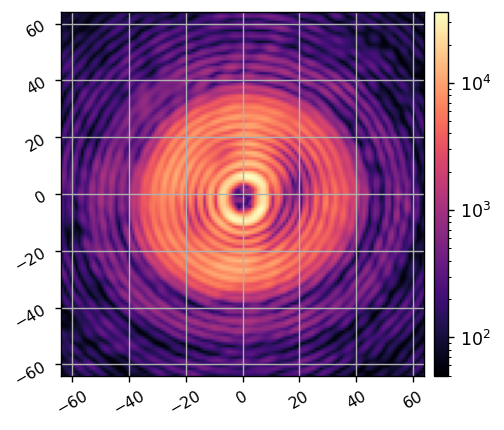

In [ ]:
ref_im = np.mean( camlo_stream.grab_many(100), axis=0)
imshow1(ref_im, grid=True, pxscl=1, lognorm=True)

In [ ]:
irad = 3
orad = 35
control_mask = llowfsc.create_control_mask(camlo_dims, irad, orad, even=1)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
imshow2(control_mask, ref_im * control_mask, grid=True, pxscl=1, lognorm2=True, vmin2=1e1)

In [ ]:
camlo_ref_channel.write(ref_im)

# Calibrate LLOWFSC with the Zernike modes we want to control

In [ ]:
reload(utils)
Nz_modes = 10
I.zero_dm()
zer_modes = ensure_np_array(utils.create_zernike_modes(I.dm_mask, nmodes=Nz_modes, remove_modes=1))
zer_modal_matrix = zer_modes.reshape(Nz_modes, -1)

In [ ]:
reload(llowfsc)
zer_calib_amp = 3e-9
zer_nframes = 10

zer_response_matrix, zer_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    zer_modes, 
    control_mask, 
    amps=zer_calib_amp, 
    NFRAMES=10, 
    dm_delay=0.001, 
    plot=True,
)

In [ ]:
zer_calib_data = {
    'response_matrix':zer_response_matrix,
    'response_cube':zer_response_cube,
    'modes':zer_modes, 
    'calib_amp':zer_calib_amp,
    'control_mask':control_mask,
    'NFRAMES':zer_nframes,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
    'fiber_atten':fib_atten,
}
utils.save_pickle(llowfsc_data_path/'zernike_calibration.pkl', zer_calib_data)

Saved data to:  ../data/llowfsc+iefc/20241217_llowfsc_zer_calib_data.pkl


In [ ]:
old_calib_path = data_path/f'exp-20250217'/'llowfsc'/'zernike_calibration.pkl'
old_calib_data = utils.load_pickle(old_calib_path)

# Define and the LLOWFSC process.

In [ ]:
lo_cm = ensure_np_array(utils.TikhonovInverse(xp.array(zer_response_matrix), 0))

gain_channel = 'llowfsc_gains'
leak_channel = 'llowfsc_leakage'
scoobi.create_shmim(gain_channel, (Nz_modes, 1))
scoobi.create_shmim(leak_channel, (1, 1)) # yes, it is a 1x1 array, shmims have to be this way

gains_stream = ImageStream(gain_channel)
leak_stream = ImageStream(leak_channel)
gains_stream.write(np.array([2*[0.5] + 8*[0.05],]))
leak_stream.write(np.array([[0.0]]))

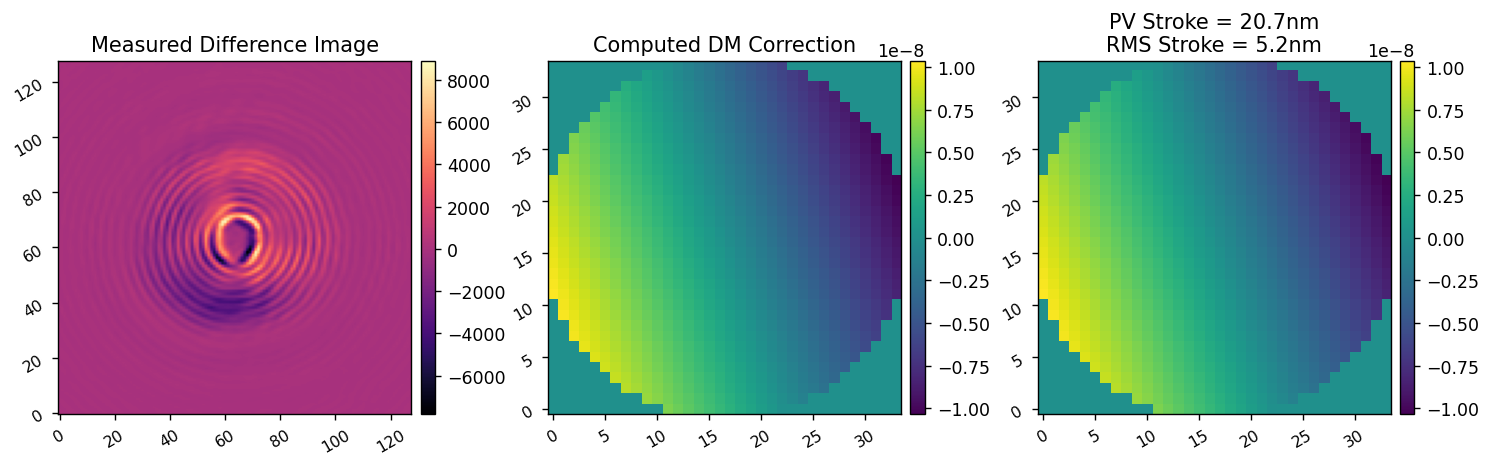

In [ ]:
reload(llowfsc)
llowfsc.single_iteration(
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_ref_delta_stream,  
    gains_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask, 
    plot=True,
)
I.zero_dm()

In [ ]:
reload(llowfsc)
reload(utils)

llowfsc_freq = 100
llowfsc_interval = 1/llowfsc_freq

args = [
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_ref_delta_stream,
    gains_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix,
    control_mask, 
    zer_modal_matrix, 
    control_mask,
]

llowfsc_process = llowfsc.Process(
    1/llowfsc_freq, 
    llowfsc.single_iteration, 
    args, # the args
    # kwargs, # the kwargs
)



# Run the LLOWFSC process

In [130]:
llowfsc_process.start()

In [134]:
llowfsc_process.cancel()
I.zero_dm()

## Adjust leakage and gains

In [ ]:
leak_stream.write(np.array([[0.02]]))

In [ ]:
gains_stream.write(np.array([2*[0.5] + 8*[0.0]]))

In [ ]:
gains_stream.write(np.array([2*[0.5] + 3*[0.2] + 5*[0.2]]))

In [ ]:
gains_stream.write(np.array([2*[0.75] + 3*[0.25] + 5*[0.25]]))